In [27]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram , linkage , fcluster
from sklearn.manifold import TSNE

In [28]:
# Download latest version
folder_path = kagglehub.dataset_download("fernandol/countries-of-the-world")

print("Path to dataset files:", folder_path)

Path to dataset files: /home/kabuga/.cache/kagglehub/datasets/fernandol/countries-of-the-world/versions/1


In [29]:
all_files = os.listdir(folder_path)
print("\n--- Files found inside this dataset ---")
for file in all_files:
    print(f"- {file}")


--- Files found inside this dataset ---
- countries of the world.csv


In [30]:
csv_file_name = 'countries of the world.csv'

In [31]:
csv_path = os.path.join(folder_path , csv_file_name)
df = pd.read_csv(csv_path)
print(df.head())

           Country                               Region  Population  \
0     Afghanistan         ASIA (EX. NEAR EAST)             31056997   
1         Albania   EASTERN EUROPE                          3581655   
2         Algeria   NORTHERN AFRICA                        32930091   
3  American Samoa   OCEANIA                                   57794   
4         Andorra   WESTERN EUROPE                            71201   

   Area (sq. mi.) Pop. Density (per sq. mi.) Coastline (coast/area ratio)  \
0          647500                       48,0                         0,00   
1           28748                      124,6                         1,26   
2         2381740                       13,8                         0,04   
3             199                      290,4                        58,29   
4             468                      152,1                         0,00   

  Net migration Infant mortality (per 1000 births)  GDP ($ per capita)  \
0         23,06                     

In [32]:
# we need to reduce the rows to about 30

In [33]:
df = df.head(30)
df

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
0,Afghanistan,ASIA (EX. NEAR EAST),31056997,647500,"48,0","0,00","23,06","163,07",700.0,"36,0","3,2","12,13","0,22","87,65",1,"46,6","20,34","0,38","0,24","0,38"
1,Albania,EASTERN EUROPE,3581655,28748,"124,6","1,26","-4,93","21,52",4500.0,"86,5","71,2","21,09","4,42","74,49",3,"15,11","5,22","0,232","0,188","0,579"
2,Algeria,NORTHERN AFRICA,32930091,2381740,"13,8","0,04","-0,39",31,6000.0,"70,0","78,1","3,22","0,25","96,53",1,"17,14","4,61","0,101","0,6","0,298"
3,American Samoa,OCEANIA,57794,199,"290,4","58,29","-20,71","9,27",8000.0,"97,0","259,5",10,15,75,2,"22,46","3,27",NaN,NaN,NaN
4,Andorra,WESTERN EUROPE,71201,468,"152,1","0,00","6,6","4,05",19000.0,"100,0","497,2","2,22",0,"97,78",3,"8,71","6,25",NaN,NaN,NaN
5,Angola,SUB-SAHARAN AFRICA,12127071,1246700,"9,7","0,13",0,"191,19",1900.0,"42,0","7,8","2,41","0,24","97,35",NaN,"45,11","24,2","0,096","0,658","0,246"
6,Anguilla,LATIN AMER. & CARIB,13477,102,"132,1","59,80","10,76","21,03",8600.0,"95,0","460,0",0,0,100,2,"14,17","5,34","0,04","0,18","0,78"
7,Antigua & Barbuda,LATIN AMER. & CARIB,69108,443,"156,0","34,54","-6,15","19,46",11000.0,"89,0","549,9","18,18","4,55","77,27",2,"16,93","5,37","0,038","0,22","0,743"
8,Argentina,LATIN AMER. & CARIB,39921833,2766890,"14,4","0,18","0,61","15,18",11200.0,"97,1","220,4","12,31","0,48","87,21",3,"16,73","7,55","0,095","0,358","0,547"
9,Armenia,C.W. OF IND. STATES,2976372,29800,"99,9","0,00","-6,47","23,28",3500.0,"98,6","195,7","17,55","2,3","80,15",4,"12,07","8,23","0,239","0,343","0,418"


In [34]:
df.shape

(30, 20)

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Country                             30 non-null     str    
 1   Region                              30 non-null     str    
 2   Population                          30 non-null     int64  
 3   Area (sq. mi.)                      30 non-null     int64  
 4   Pop. Density (per sq. mi.)          30 non-null     str    
 5   Coastline (coast/area ratio)        30 non-null     str    
 6   Net migration                       30 non-null     str    
 7   Infant mortality (per 1000 births)  30 non-null     str    
 8   GDP ($ per capita)                  30 non-null     float64
 9   Literacy (%)                        29 non-null     str    
 10  Phones (per 1000)                   30 non-null     str    
 11  Arable (%)                          30 non-null     str   

In [36]:
# chec if columns have nullvalues as we expect to have 227 rows

df.isnull().sum()

Country                               0
Region                                0
Population                            0
Area (sq. mi.)                        0
Pop. Density (per sq. mi.)            0
Coastline (coast/area ratio)          0
Net migration                         0
Infant mortality (per 1000 births)    0
GDP ($ per capita)                    0
Literacy (%)                          1
Phones (per 1000)                     0
Arable (%)                            0
Crops (%)                             0
Other (%)                             0
Climate                               1
Birthrate                             0
Deathrate                             0
Agriculture                           2
Industry                              2
Service                               2
dtype: int64

In [37]:
# 14 columns have null values we drop all null values or fill them with 0

df_cleaned = df.fillna(0)
print(df_cleaned.isnull().sum())

Country                               0
Region                                0
Population                            0
Area (sq. mi.)                        0
Pop. Density (per sq. mi.)            0
Coastline (coast/area ratio)          0
Net migration                         0
Infant mortality (per 1000 births)    0
GDP ($ per capita)                    0
Literacy (%)                          0
Phones (per 1000)                     0
Arable (%)                            0
Crops (%)                             0
Other (%)                             0
Climate                               0
Birthrate                             0
Deathrate                             0
Agriculture                           0
Industry                              0
Service                               0
dtype: int64


In [38]:
# UNSUPERVISED LEARNING TECHNIQUES FOR DATA VISUALISATION

# THERE ARE 2 TECHNIQUES FOR THIS :
        # 1. Hierarchacal clustering
        # 2. t-SNE



In [39]:
# HIERARCHICAL CLUSTERING

# Arranges samples into a hierachy of clusters
# The diagram visualised is caleed a Dendrogram


# HOW TO IMPLIMENT HIERACHICAL CLUSTERING'

# Import linkage and dendrogram
# instantiate a linkage model and pass in our data that we want to perform hierachical clustering (specify method = complete or single)
# pass the output in the step above to the dendogram method

In [40]:
Country_att = (
    df_cleaned.drop(columns=['Country', 'Region'])
    .replace(',', '.', regex=True)
    .apply(pd.to_numeric, errors='coerce')
    .fillna(0)
)
country_names = df_cleaned['Country']



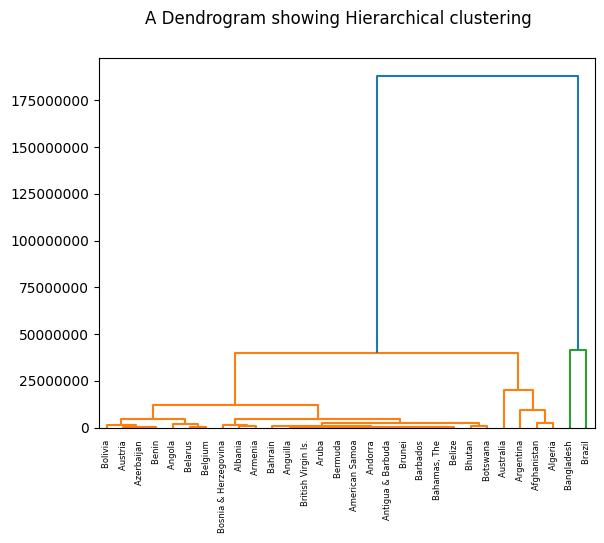

In [41]:

height_of_dendrogram = linkage(Country_att , method = 'complete')

# pass the linkages above(grouped into clusters) into a dedrogram to visualize
dendrogram(
    height_of_dendrogram , 
    labels = country_names.tolist(), 
    leaf_rotation = 90 , 
    leaf_font_size = 6
)
plt.suptitle("A Dendrogram showing Hierarchical clustering")
plt.ticklabel_format(style='plain', axis='y')
plt.show()


In [45]:
# HOW TO EXTRACT DIFFERENT CLUSTERS IN THE HIERACHICAL CLUSTERING

# 1. we need to identify a height of the dendrogram(y-axis on dedrogram = distance between the merging clusters)

# 2.After identifying the height , we need to extract the clusters using the fcluster function

# paramters we specify are: results after merging ,height to identify cluster we want , crtiterion = 'distance'


labels_2 = fcluster(height_of_dendrogram , 25000000 , criterion = 'distance')

pairs = pd.DataFrame({'labels' : labels_2 , 'countries' : country_names.tolist()})

print(pairs.sort_values('labels'))

    labels              countries
1        1               Albania 
3        1        American Samoa 
5        1                Angola 
4        1               Andorra 
6        1              Anguilla 
7        1     Antigua & Barbuda 
10       1                 Aruba 
9        1               Armenia 
14       1          Bahamas, The 
15       1               Bahrain 
13       1            Azerbaijan 
12       1               Austria 
20       1                Belize 
19       1               Belgium 
18       1               Belarus 
17       1              Barbados 
29       1                Brunei 
25       1  Bosnia & Herzegovina 
26       1              Botswana 
28       1    British Virgin Is. 
22       1               Bermuda 
21       1                 Benin 
23       1                Bhutan 
24       1               Bolivia 
8        2             Argentina 
11       2             Australia 
2        2               Algeria 
0        2           Afghanistan 
16       3    

In [43]:
# TSNE UNSUPERVISED LEARNING VISUALISATION TECHNIQUE

# TSNE = T-distributed stochastic neighbour enbedding

# it maps samples from their higher dimensional space into a 2 -3 domensional space


Path to dataset files: /home/kabuga/.cache/kagglehub/datasets/ameythakur20/unsupervisedlearning/versions/1

--- Files found inside this dataset ---
- Iris.csv
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
==== Cleaned Features For Clustering======
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6      

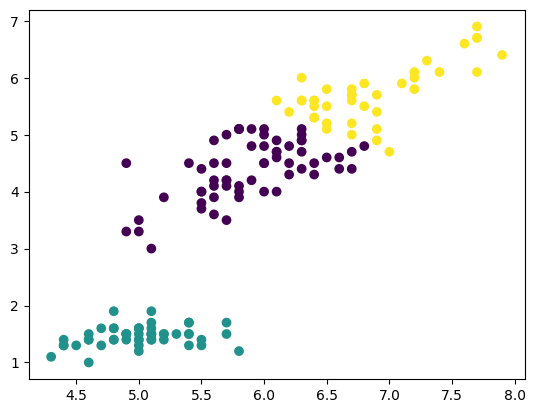

========EVALUATING A CLUSTERING=============
species  Iris-setosa  Iris-versicolor  Iris-virginica
labels                                               
0                  0               47              14
1                 50                0               0
2                  0                3              36
[680.8244000000001]
[680.8244000000001, 152.36870647733903]
[680.8244000000001, 152.36870647733903, 78.94084142614601]
[680.8244000000001, 152.36870647733903, 78.94084142614601, 57.34540931571816]
[680.8244000000001, 152.36870647733903, 78.94084142614601, 57.34540931571816, 50.189522106849644]


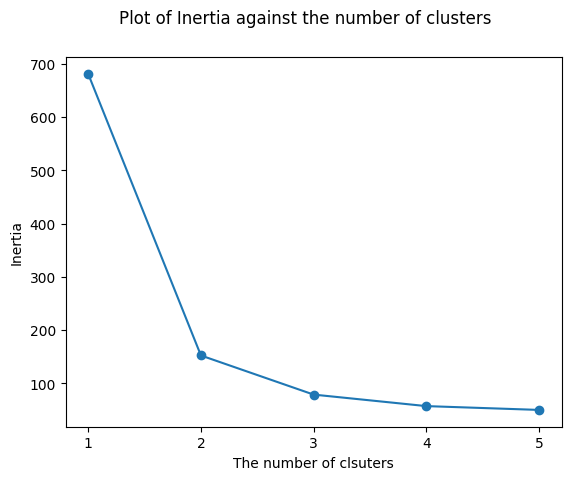

In [44]:
import json
from pathlib import Path

# we need to import the notebook that contains the iris dataset

nb_path = Path("clustering_iris.ipynb")

with nb_path.open(encoding="utf-8") as f:
    nb = json.load(f)

for cell in nb.get("cells", []):
    if cell.get("cell_type") == "code":
        source = "".join(cell.get("source", []))
        if source.strip():
            exec(source, globals())




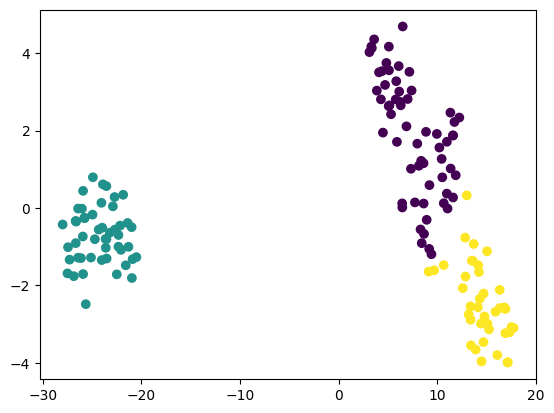

In [46]:
# Create the TSNE Instance

model = TSNE(learning_rate = 50)

# apply the fit_transform to the X features from the iris

tsne_features = model.fit_transform(X)

# select the feature atht the 1st position and 2nd position

xs = tsne_features[: , 0]
ys = tsne_features[: , 1]

# plot a scatter plot for this

plt.scatter(xs ,ys , c = labels)

plt.show()